In [1]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from PIL import Image
from mttoy import Params, run_simulation
from mttoy.viz import render_state, trim_white

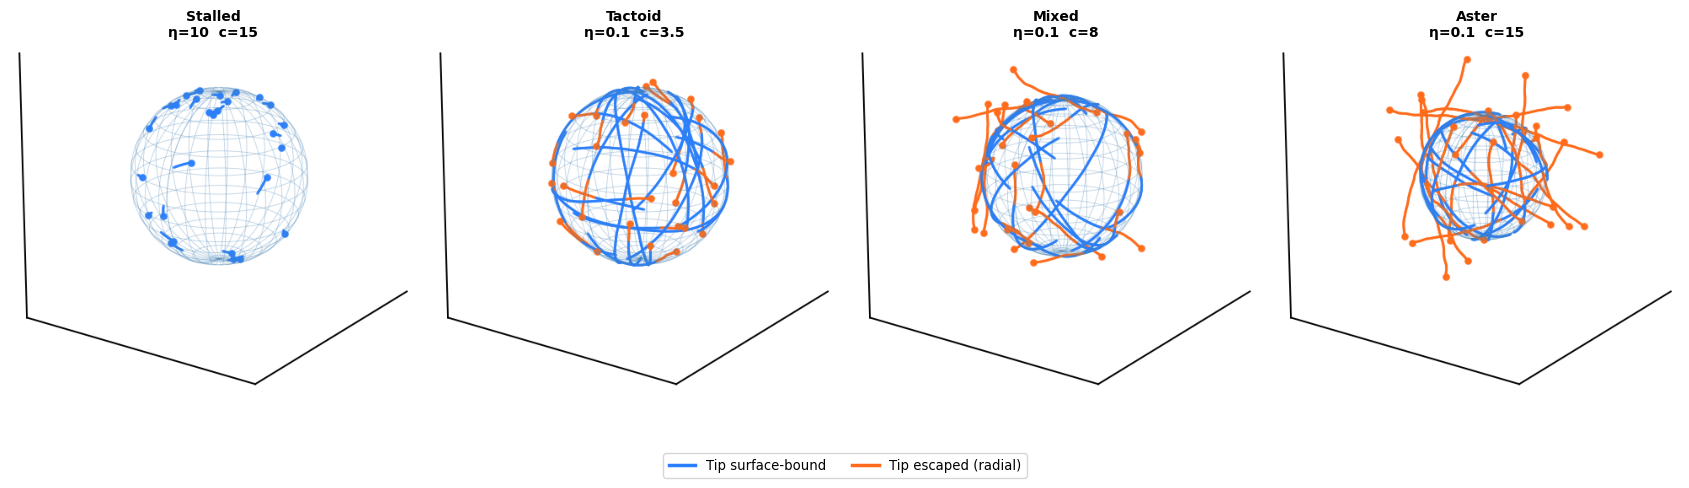

In [3]:
SHARED = dict(
    R=8.0,
    # surface replenishment / bulk growth
    k0_ads=0.14/8.0,
    k0_on=3e-3,

    # nucleation
    k0_nuc=2e-4,
    n_nuc_thresh=6.0,
    dn_nuc=8.0,

    # growth
    k_plus_surf=0.11,
    D0_grow=4.0,
    dn_grow=3.0,
    ds=0.18,

    # peeling 
    k0_off=0.005,
    n_thresh=1.,
    w_thresh=0.30,

    # numerics / morphology
    L_p=1000,
    noise_free=0.05,
    max_mts=28,
    init_surface_frac=0.45
)

runs = [
    (Params(name='Stalled\nη=10  c=15',  eta_eff=10.0, c_bulk=15.0, **SHARED), 2000),
    (Params(name='Tactoid\nη=0.1  c=3.5', eta_eff=0.1,  c_bulk=3.5,  **SHARED), 2000),
    (Params(name='Mixed\nη=0.1  c=8',    eta_eff=0.1,  c_bulk=8.0,  **SHARED), 2000),
    (Params(name='Aster\nη=0.1  c=15',   eta_eff=0.1,  c_bulk=15.0, **SHARED), 2000),
]

os.makedirs("figures/snaps", exist_ok=True)
pngs = []
for i, (p, T) in enumerate(runs):
    result = run_simulation(p, T_end=T, seed=42+i)
    st = result["final_state"]
    path = f"figures/snaps/cond_{i}.png"
    render_state(st, path, elev=20, azim=35)
    im = trim_white(Image.open(path).convert("RGB"), pad=10)
    im.save(path)
    pngs.append(path)

fig, axes = plt.subplots(1, 4, figsize=(17, 5))
for ax, path, (p, T) in zip(axes, pngs, runs):
    ax.imshow(Image.open(path))
    ax.set_title(p.name, fontsize=10, fontweight="bold")
    ax.axis("off")

fig.legend(handles=[
    Line2D([0],[0], color='#2a7fff', lw=2.5, label='Tip surface-bound'),
    Line2D([0],[0], color='#ff6b1a', lw=2.5, label='Tip escaped (radial)'),
], loc='lower center', ncol=2, fontsize=9.5, bbox_to_anchor=(0.5, -0.03))

plt.tight_layout()
plt.savefig("figures/snapshots.png", dpi=150, bbox_inches="tight")
plt.show()

## Panel A — Interface viscosity controls MT growth kinetics

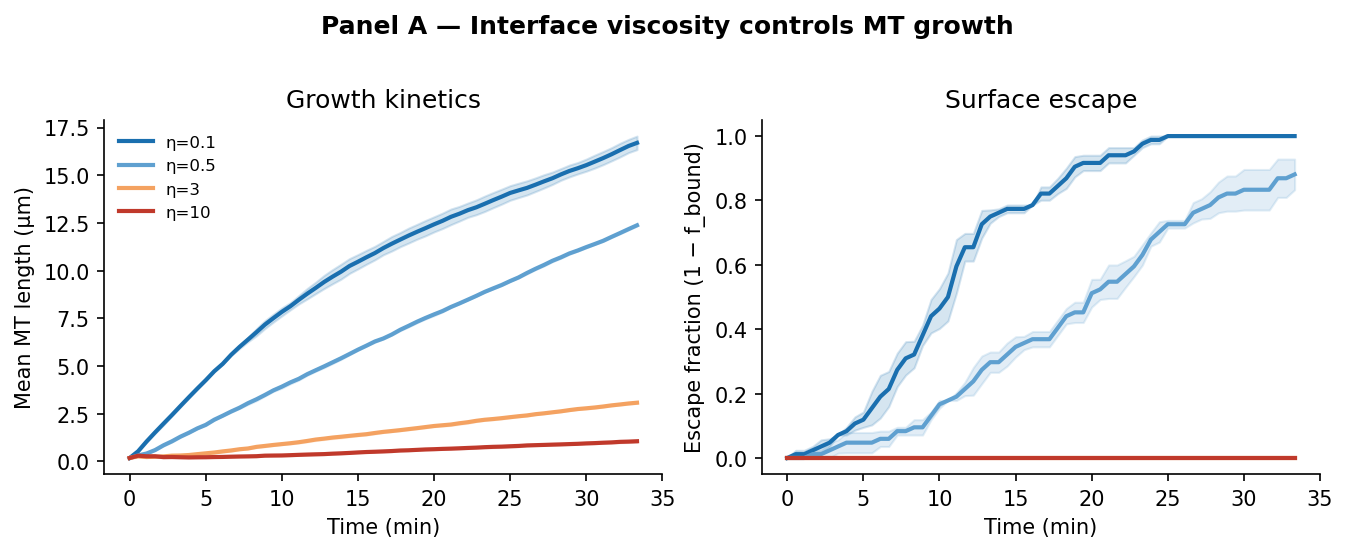

Saved panel_A.pdf


In [5]:
# Panel A — η sweep: mean MT length and escape fraction vs time
# Fixed c_bulk=10; vary eta_eff across KGKGG→RGRGG range.

ETA_SCAN = [
    ("η=0.1", 0.1,  "#1a6faf"),
    ("η=0.5",       0.5,  "#5fa0d0"),
    ("η=3",         3.0,  "#f4a261"),
    ("η=10", 10.0,  "#c0392b"),
]
SEEDS_A = [42, 43, 44]
T_A = 2000.0

rec_A = []
for label, eta, color in ETA_SCAN:
    for seed in SEEDS_A:
        p = Params(name=label, eta_eff=eta, c_bulk=10.0, **SHARED)
        out = run_simulation(p, T_end=T_A, seed=seed, sample_n=61)
        df = out["metrics"].copy()
        df["label"], df["eta_eff"], df["color"], df["seed"] = label, eta, color, seed
        rec_A.append(df)

import pandas as pd
df_A = pd.concat(rec_A, ignore_index=True)
df_Am = (df_A.groupby(["label", "eta_eff", "color", "t"])
              .agg(mean_L    =("mean_L",        "mean"),
                   sem_L     =("mean_L",        "sem"),
                   escape    =("escape_index",  "mean"),
                   sem_esc   =("escape_index",  "sem"),
                   n_mt      =("n_mt",          "mean"),
                   sem_nmt   =("n_mt",          "sem"))
              .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6), dpi=150)
for label, eta, color in ETA_SCAN:
    s = df_Am[df_Am["label"] == label]
    t = s["t"].values / 60   # convert to minutes
    axes[0].plot(t, s["mean_L"], color=color, lw=2, label=label)
    axes[0].fill_between(t,
        s["mean_L"] - s["sem_L"], s["mean_L"] + s["sem_L"],
        color=color, alpha=0.18)
    axes[1].plot(t, s["escape"], color=color, lw=2)
    axes[1].fill_between(t,
        s["escape"] - s["sem_esc"], s["escape"] + s["sem_esc"],
        color=color, alpha=0.18)

axes[0].set_xlabel("Time (min)"); axes[0].set_ylabel("Mean MT length (μm)")
axes[0].set_title("Growth kinetics"); axes[0].legend(fontsize=8, frameon=False)
axes[1].set_xlabel("Time (min)"); axes[1].set_ylabel("Escape fraction (1 − f_bound)")
axes[1].set_title("Surface escape")
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.suptitle("Panel A — Interface viscosity controls MT growth", fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("figures/panel_A.pdf", bbox_inches="tight")
plt.show()
print("Saved panel_A.pdf")

## Panel B — Droplet radius (R) dependence

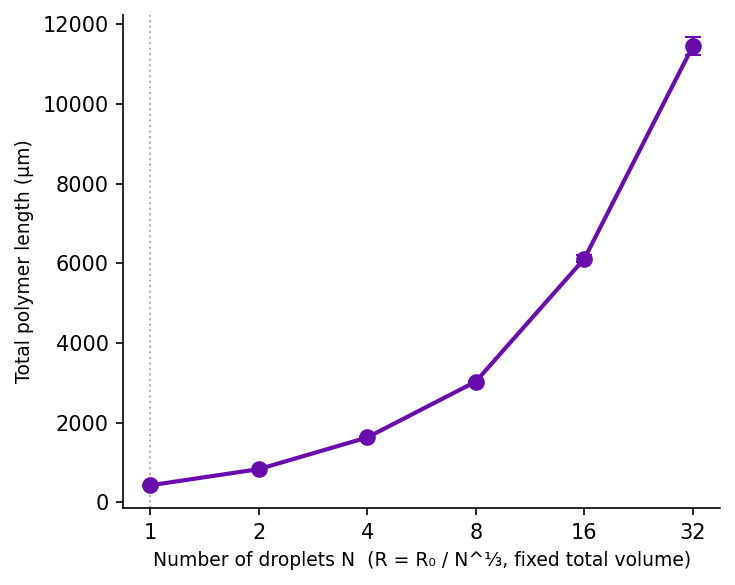

Saved panel_B.pdf


In [ ]:
# Panel B — Fixed total condensate volume, fragmented into N droplets.
# Volume conservation: N × (4/3)π r³ = const  →  r = R₀ / N^(1/3)
# Total polymer length = N × n_mt × mean_L  (experiment-comparable: turbidity/pelleting)

from mttoy import Params, run_simulation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

R0       = 8.0
N_VALS   = [1, 2, 4, 8, 16, 32]
ETA_KG   = 0.1
C_B      = 10.0
SEEDS_B  = [42, 43, 44]
T_B      = 2000.0
shared_no_R = {k: v for k, v in SHARED.items() if k != "R"}

rows = []
for N in N_VALS:
    R = R0 / (N ** (1.0 / 3.0))
    rec = []
    for seed in SEEDS_B:
        p = Params(name=f"N={N}", R=R, eta_eff=ETA_KG, c_bulk=C_B, **shared_no_R)
        out = run_simulation(p, T_end=T_B, seed=seed, sample_n=61)
        df  = out["metrics"]
        tail = df.iloc[int(0.75 * len(df)):]
        rec.append(dict(
            n_mt   = tail["n_mt"].mean(),
            mean_L = tail["mean_L"].mean(),
        ))
    tdf = pd.DataFrame(rec)
    polymer_per = tdf["n_mt"] * tdf["mean_L"]
    rows.append(dict(
        N            = N,
        R            = R,
        polymer_tot  = N * polymer_per.mean(),
        sem_polymer  = N * polymer_per.sem(),
    ))

df_B = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(5, 4), dpi=150)
ax.errorbar(df_B["N"], df_B["polymer_tot"], yerr=df_B["sem_polymer"],
            color="#6a0dad", marker="o", lw=2, capsize=4, markersize=7)
ax.set_xscale("log", base=2)
ax.set_xticks(N_VALS); ax.set_xticklabels([str(n) for n in N_VALS])
ax.set_xlabel(r"Number of droplets N  ($R = R_0 / N^{1/3}$, fixed total volume)", fontsize=9)
ax.set_ylabel("Total polymer length (μm)", fontsize=9)
#ax.set_title("Panel B — Fragmentation at fixed condensate volume\n"
             #f"(R₀={R0} μm, η={ETA_KG}, c={C_B})", fontweight="bold")
ax.axvline(1, color="gray", lw=1, linestyle=":", alpha=0.6)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("figures/panel_B.pdf", bbox_inches="tight")
plt.show()
print("Saved panel_B.pdf")

## Panel C — Morphology transition: tactoid → mixed → aster

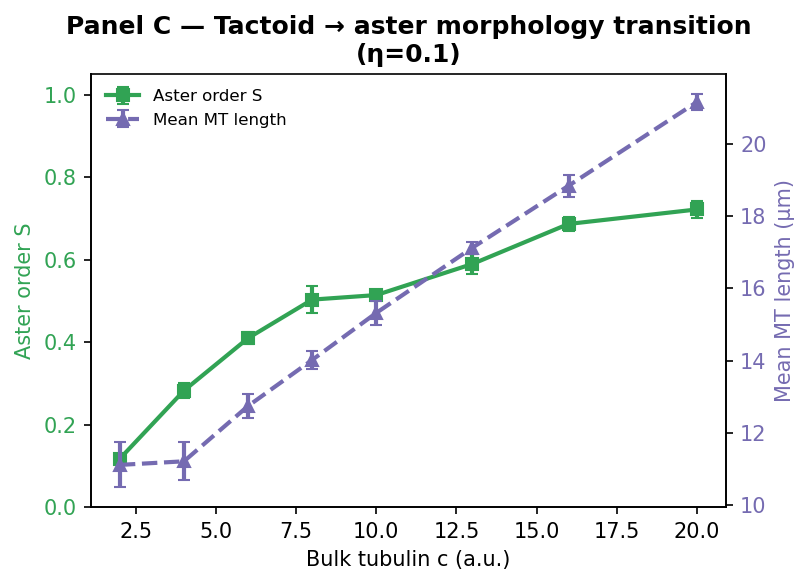

Saved panel_C.pdf


In [7]:
# Panel C — c_bulk sweep at low η: aster order S vs tubulin concentration.
# Captures the tactoid → aster transition as c_bulk rises.

from mttoy.analysis import run_point
import pandas as pd

C_VALS  = [2.0, 4.0, 6.0, 8.0, 10.0, 13.0, 16.0, 20.0]
ETA_LOW = 0.1
base_C  = Params(name="KGKGG", eta_eff=ETA_LOW, c_bulk=1.0, **SHARED)

rows_C = []
for c in C_VALS:
    res = run_point(base_C, c_bulk=c, eta_eff=ETA_LOW, seeds=[42, 43, 44], T_end=2000)
    rows_C.append(dict(c_bulk=c,
                        aster  =res.get("aster_mean",  float("nan")),
                        sem_ast=res.get("aster_sem",   0.0),
                        mean_L =res.get("meanL_mean",  float("nan")),
                        sem_L  =res.get("meanL_sem",   0.0)))
df_C = pd.DataFrame(rows_C)

fig, ax1 = plt.subplots(figsize=(5.5, 4.0), dpi=150)
ax2 = ax1.twinx()

ax1.errorbar(df_C["c_bulk"], df_C["aster"], yerr=df_C["sem_ast"],
             color="#31a354", marker="s", lw=2, capsize=3, label="Aster order S")
ax2.errorbar(df_C["c_bulk"], df_C["mean_L"], yerr=df_C["sem_L"],
             color="#756bb1", marker="^", lw=2, capsize=3, linestyle="--", label="Mean MT length")

ax1.set_xlabel("Bulk tubulin c (a.u.)")
ax1.set_ylabel("Aster order S",       color="#31a354")
ax2.set_ylabel("Mean MT length (μm)", color="#756bb1")
ax1.tick_params(axis="y", labelcolor="#31a354")
ax2.tick_params(axis="y", labelcolor="#756bb1")
ax1.set_ylim(0, 1.05)
ax1.spines[["top"]].set_visible(False)

lines1, lbl1 = ax1.get_legend_handles_labels()
lines2, lbl2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lbl1 + lbl2, fontsize=8, frameon=False, loc="upper left")
ax1.set_title("Panel C — Tactoid → aster morphology transition\n(η=0.1)", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/panel_C.pdf", bbox_inches="tight")
plt.show()
print("Saved panel_C.pdf")

## Save / Load simulation data (CSV)

In [10]:
import os
import pandas as pd

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

# ── Save ──────────────────────────────────────────────────────────────────────
df_A.to_csv(f"{DATA_DIR}/df_A_eta_sweep.csv", index=False)
df_B.to_csv(f"{DATA_DIR}/df_B_droplet_radius.csv", index=False)
df_C.to_csv(f"{DATA_DIR}/df_C_morphology.csv", index=False)
print("Saved CSVs to", DATA_DIR)

# ── Load (run this block instead of re-running simulations) ───────────────────
# df_A = pd.read_csv(f"{DATA_DIR}/df_A_eta_sweep.csv")
# df_B = pd.read_csv(f"{DATA_DIR}/df_B_droplet_radius.csv")
# df_C = pd.read_csv(f"{DATA_DIR}/df_C_morphology.csv")
# df_Am = (df_A.groupby(["label", "eta_eff", "color", "t"])
#               .agg(mean_L  =("mean_L",       "mean"),
#                    sem_L   =("mean_L",        "sem"),
#                    escape  =("escape_index",  "mean"),
#                    sem_esc =("escape_index",  "sem"),
#                    n_mt    =("n_mt",          "mean"),
#                    sem_nmt =("n_mt",          "sem"))
#               .reset_index())
# print("Loaded CSVs from", DATA_DIR)

Saved CSVs to data


# Composite figure

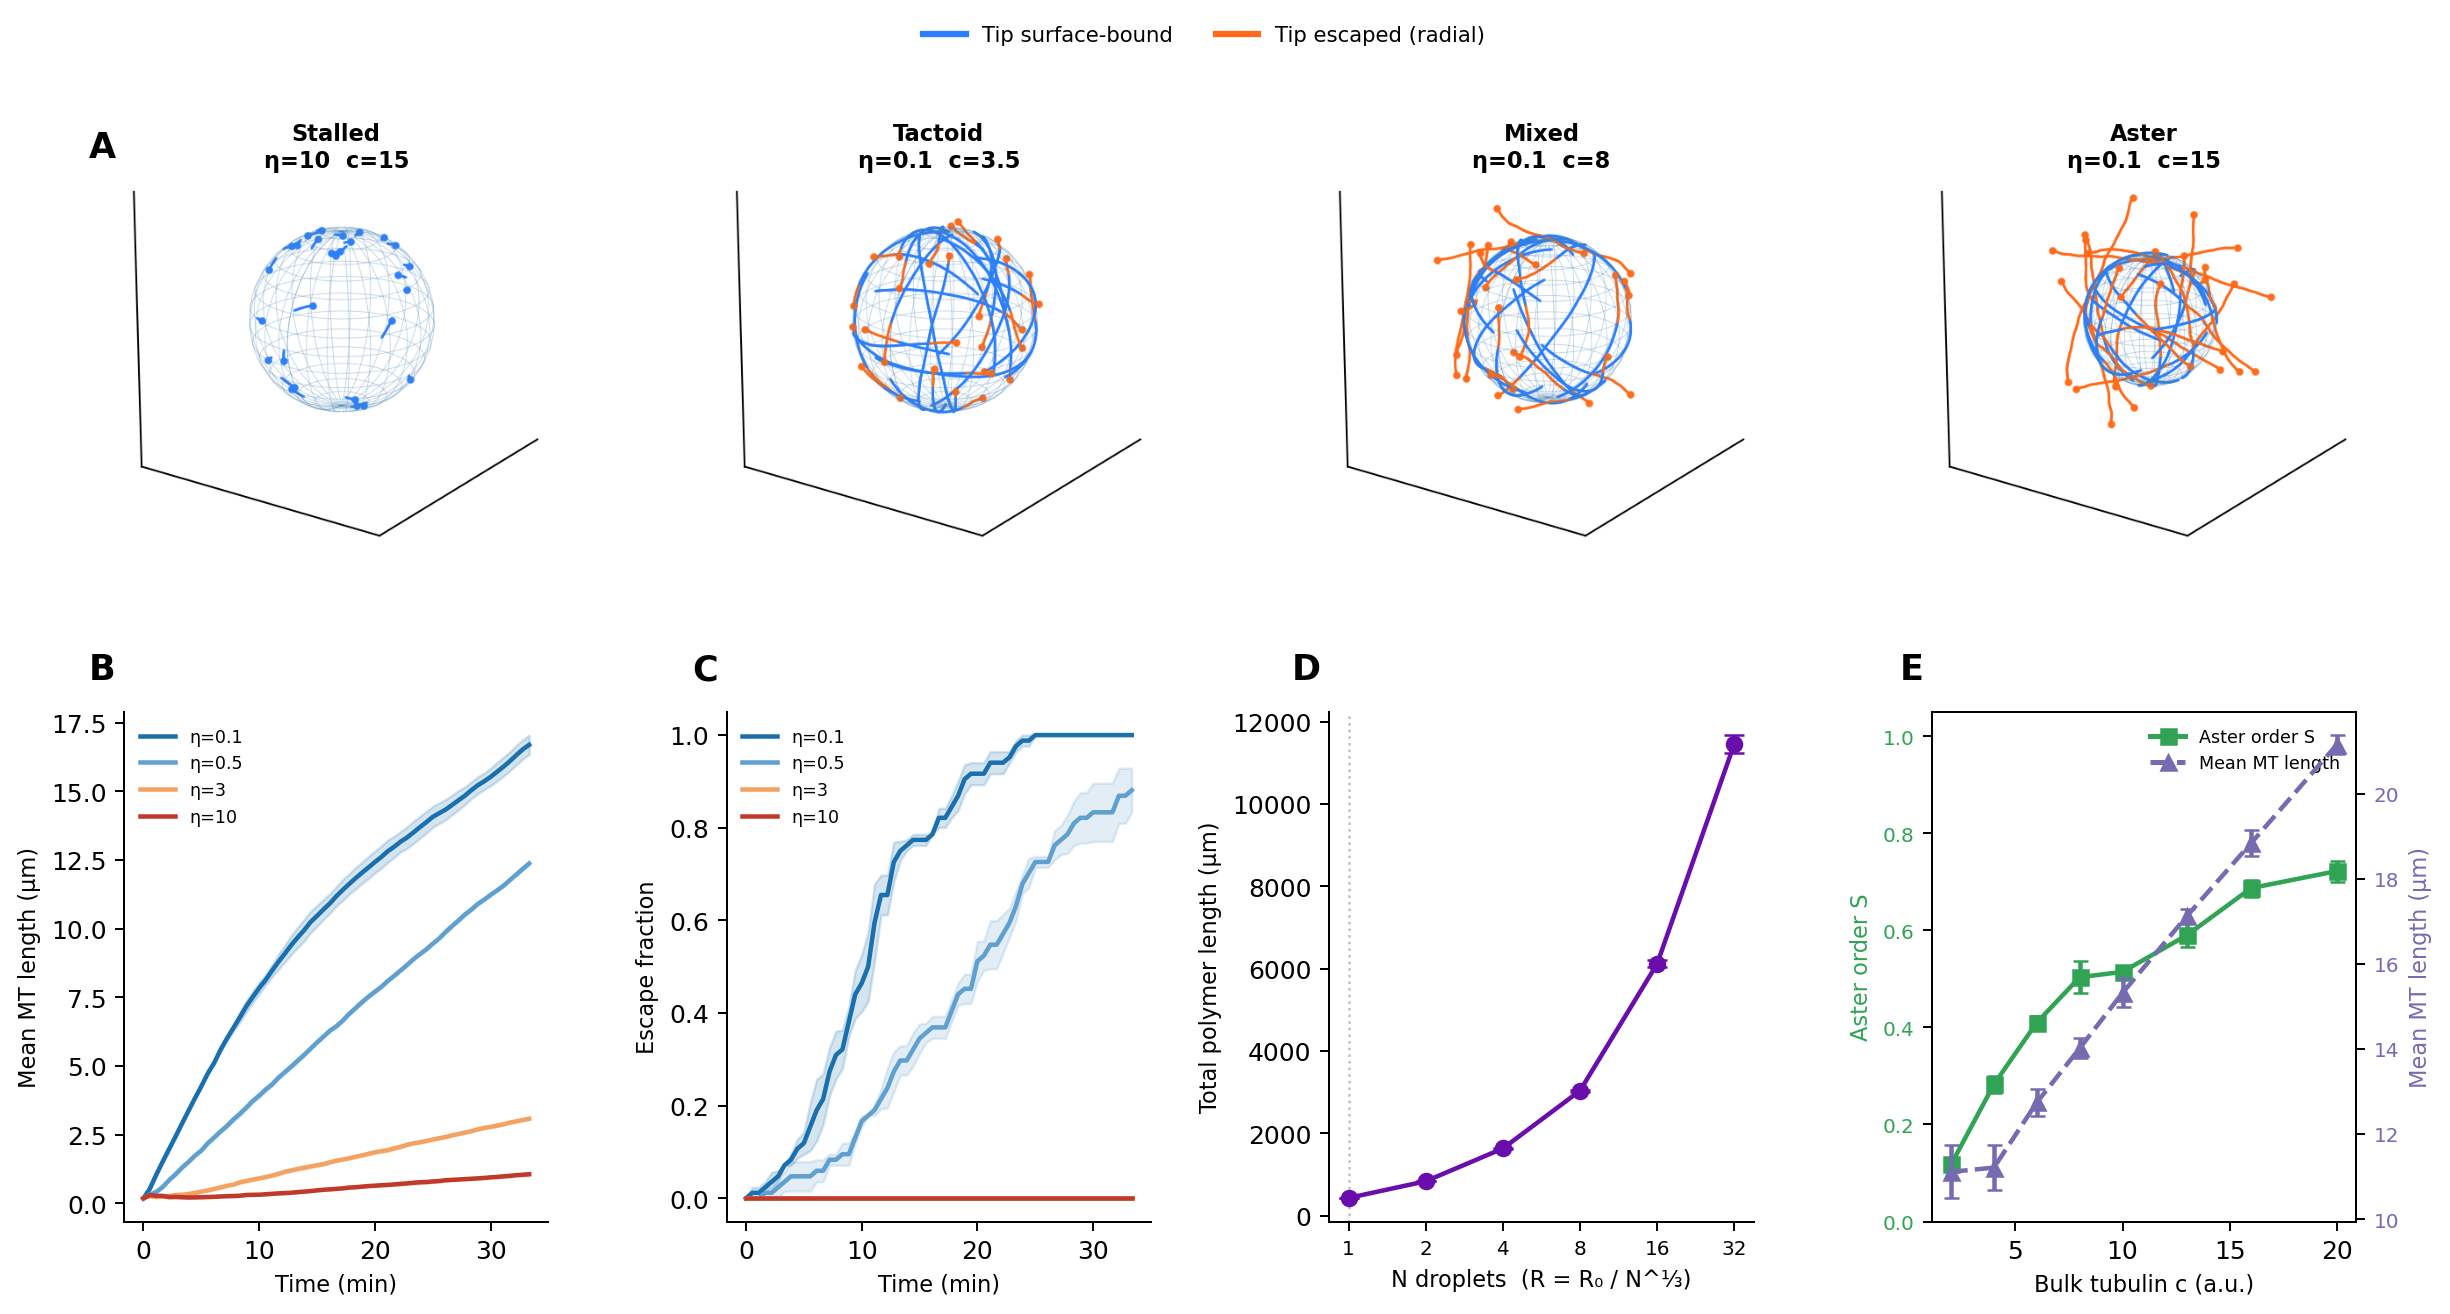

Saved figure_combined.pdf / .png


In [9]:
# Combined publication figure
# Row 0: snapshots (A)  |  Row 1: B (mean_L) · C (escape) · D (total polymer) · E (aster S)

from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from PIL import Image

fig = plt.figure(figsize=(16, 7.5), dpi=180)
gs  = GridSpec(2, 4, figure=fig,
               height_ratios=[1, 1.4],
               hspace=0.38, wspace=0.42)

def panel_label(ax, lbl):
    ax.text(-0.02, 1.05, lbl, transform=ax.transAxes,
            fontsize=14, fontweight="bold", va="bottom", ha="right")

# ── Row 0: snapshots (label A on first panel) ─────────────────────────────────
# Reconstruct pngs/runs from disk if kernel was restarted
if 'runs' not in dir():
    runs = [
        (Params(name='Stalled\nη=10  c=15',  eta_eff=10.0, c_bulk=15.0, **SHARED), 2000),
        (Params(name='Tactoid\nη=0.1  c=3.5', eta_eff=0.1,  c_bulk=3.5,  **SHARED), 2000),
        (Params(name='Mixed\nη=0.1  c=8',    eta_eff=0.1,  c_bulk=8.0,  **SHARED), 2000),
        (Params(name='Aster\nη=0.1  c=15',   eta_eff=0.1,  c_bulk=15.0, **SHARED), 2000),
    ]
if 'pngs' not in dir():
    pngs = [f"figures/snaps/cond_{i}.png" for i in range(len(runs))]

for col, (path, (p, T)) in enumerate(zip(pngs, runs)):
    ax = fig.add_subplot(gs[0, col])
    ax.imshow(Image.open(path))
    ax.set_title(p.name, fontsize=9, fontweight="bold")
    ax.axis("off")
    if col == 0:
        ax.text(-0.02, 1.05, "A", transform=ax.transAxes,
                fontsize=14, fontweight="bold", va="bottom", ha="right")

fig.legend(handles=[
    Line2D([0],[0], color='#2a7fff', lw=2.5, label='Tip surface-bound'),
    Line2D([0],[0], color='#ff6b1a', lw=2.5, label='Tip escaped (radial)'),
], loc='upper center', ncol=2, fontsize=8.5,
   bbox_to_anchor=(0.5, 1.01), frameon=False)

# ── Panel B: mean MT length vs time ──────────────────────────────────────────
ax_b = fig.add_subplot(gs[1, 0])
for label, eta, color in ETA_SCAN:
    s = df_Am[df_Am["label"] == label]
    t = s["t"].values / 60
    ax_b.plot(t, s["mean_L"], color=color, lw=1.8, label=label)
    ax_b.fill_between(t, s["mean_L"] - s["sem_L"], s["mean_L"] + s["sem_L"],
                      color=color, alpha=0.18)
ax_b.set_xlabel("Time (min)", fontsize=9)
ax_b.set_ylabel("Mean MT length (μm)", fontsize=9)
ax_b.legend(fontsize=7, frameon=False)
ax_b.spines[["top", "right"]].set_visible(False)
panel_label(ax_b, "B")

# ── Panel C: escape fraction vs time ─────────────────────────────────────────
ax_c = fig.add_subplot(gs[1, 1])
for label, eta, color in ETA_SCAN:
    s = df_Am[df_Am["label"] == label]
    t = s["t"].values / 60
    ax_c.plot(t, s["escape"], color=color, lw=1.8, label=label)
    ax_c.fill_between(t, s["escape"] - s["sem_esc"], s["escape"] + s["sem_esc"],
                      color=color, alpha=0.18)
ax_c.set_xlabel("Time (min)", fontsize=9)
ax_c.set_ylabel("Escape fraction", fontsize=9)
ax_c.legend(fontsize=7, frameon=False)
ax_c.spines[["top", "right"]].set_visible(False)
panel_label(ax_c, "C")

# ── Panel D: total polymer vs N droplets ─────────────────────────────────────
ax_d = fig.add_subplot(gs[1, 2])
ax_d.errorbar(df_B["N"], df_B["polymer_tot"], yerr=df_B["sem_polymer"],
              color="#6a0dad", marker="o", lw=1.8, capsize=4, markersize=6)
ax_d.set_xscale("log", base=2)
ax_d.set_xticks(N_VALS); ax_d.set_xticklabels([str(n) for n in N_VALS], fontsize=8)
ax_d.set_xlabel("N droplets  (R = R₀ / N^⅓)", fontsize=9)
ax_d.set_ylabel("Total polymer length (μm)", fontsize=9)
ax_d.axvline(1, color="gray", lw=1, linestyle=":", alpha=0.5)
ax_d.spines[["top", "right"]].set_visible(False)
panel_label(ax_d, "D")

# ── Panel E: aster order S + mean_L vs c_bulk ────────────────────────────────
ax_e = fig.add_subplot(gs[1, 3])
ax_e2 = ax_e.twinx()
ax_e.errorbar(df_C["c_bulk"], df_C["aster"], yerr=df_C["sem_ast"],
              color="#31a354", marker="s", lw=1.8, capsize=3, label="Aster order S")
ax_e2.errorbar(df_C["c_bulk"], df_C["mean_L"], yerr=df_C["sem_L"],
               color="#756bb1", marker="^", lw=1.8, capsize=3, linestyle="--",
               label="Mean MT length")
ax_e.set_xlabel("Bulk tubulin c (a.u.)", fontsize=9)
ax_e.set_ylabel("Aster order S",        color="#31a354", fontsize=9)
ax_e2.set_ylabel("Mean MT length (μm)", color="#756bb1", fontsize=9)
ax_e.tick_params(axis="y", labelcolor="#31a354", labelsize=8)
ax_e2.tick_params(axis="y", labelcolor="#756bb1", labelsize=8)
ax_e.set_ylim(0, 1.05)
ax_e.spines[["top"]].set_visible(False)
ax_e.legend([Line2D([0],[0], color="#31a354", lw=2, marker="s"),
             Line2D([0],[0], color="#756bb1", lw=2, marker="^", linestyle="--")],
            ["Aster order S", "Mean MT length"], fontsize=7, frameon=False)
panel_label(ax_e, "E")

plt.savefig("figures/figure_combined.pdf", bbox_inches="tight")
plt.savefig("figures/figure_combined.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved figure_combined.pdf / .png")

### Supporting info

In [ ]:
from mttoy.core import Params, run_simulation
from mttoy.viz import gif_from_states

p = Params(
    name="KGKGG_low_eta",
    eta_eff=0.1,
    c_bulk=10.0,
    **SHARED
)

out = run_simulation(
    p,
    T_end=2000,
    seed=42,
    sample_n=41,
    snapshot_dt=40.0
)

snaps = out["snapshots"]

gif_path = gif_from_states(
    snaps,
    out_gif="figures/kgkgg_sim.gif",
    duration_ms=500
)

print(gif_path)

./kgkgg_sim.gif
